# GradientBoostingClassifier
Training, tuning and held-out testing. Use the included encoded data before numeric scaling.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
while not (ROOT / 'train.py').exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Extract and open the extracted member project first. For Colab, upload the ZIP and unzip it, then change to that project directory.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.common import candidates, make_pipeline, fit_pipeline, scores, evaluate, load_train


In [2]:
KEY = 'GradientBoosting'
manifest = json.loads((ROOT / 'results/data_manifest.json').read_text())
print({k:manifest[k] for k in ['training_rows','test_rows','input_features','tuning_rows']})
print('Target: History of Mental Illness; No=0, Yes=1')

{'training_rows': 326888, 'test_rows': 81723, 'input_features': 24, 'tuning_rows': 18000}
Target: History of Mental Illness; No=0, Yes=1


In [3]:
X_train, y_train = load_train()
print('Training shape:', X_train.shape)
display(X_train.head())
print(y_train.value_counts())

Training shape: (326888, 24)


,Age,Number of Children,Income,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Education Level_Bachelor's Degree,...,Smoking Status_Non-smoker,Physical Activity Level_Moderate,Physical Activity Level_Sedentary,Employment Status_Unemployed,Alcohol Consumption_Low,Alcohol Consumption_Moderate,Dietary Habits_Moderate,Dietary Habits_Unhealthy,Sleep Patterns_Good,Sleep Patterns_Poor
0,70,3,73411.54,0,1,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
1,54,2,41223.14,0,0,1,1,0,0,0,...,1,0,1,0,0,1,1,0,0,1
2,73,0,61437.47,0,0,0,1,0,0,0,...,1,0,1,0,0,1,1,0,0,0
3,21,0,57418.96,1,0,1,1,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,49,2,27149.77,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,1,0,0


History of Mental Illness
0    227108
1     99780
Name: count, dtype: int64


In [4]:
specs = candidates(KEY)
display(pd.DataFrame([{'variant':s['name'],'scaling':s['scaling'],'weight':s['weight'],**s['params']} for s in specs]))
pipeline_example = make_pipeline(KEY, specs[0], X_train.columns)
print(pipeline_example)

,variant,scaling,weight,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample
0,gb_baseline,none,none,60,0.10,2,20,1.0
1,gb_balanced_depth2,none,balanced,80,0.05,2,30,0.8
2,gb_balanced_depth3_scaled,standard,balanced,100,0.05,3,50,0.8


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Number of Children',
                                                   'Income']),
                                                 ('encoded',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['History of Substance Abuse',
                                                   'Family History of '
                                                   'Depression',
                                                   'Chronic Medical Conditions',
                                                   'Marital Status_Married',
                                                   'Mari

## Training implementation

In [5]:
"""Training and tuning only. Never reads final-test features or labels."""
import argparse,json,time,warnings
import numpy as np,pandas as pd,joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.exceptions import ConvergenceWarning
from src.common import ROOT,SEED,MODEL_INFO,candidates,make_pipeline,fit_pipeline,evaluate,scores,load_train

def train_model(key):
 X,y=load_train();pos=np.load(ROOT/'data/prepared/tuning_train_positions.npy');Xt,yt=X.iloc[pos].reset_index(drop=True),y.iloc[pos].reset_index(drop=True)
 cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=SEED);folds=[];summary=[];best=None
 for spec in candidates(key):
  f1s=[]
  for fold,(tr,va) in enumerate(cv.split(Xt,yt),1):
   print(f'TUNING {key} {spec["name"]} fold {fold}',flush=True)
   pipe=make_pipeline(key,spec,X.columns);started=time.perf_counter()
   with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always');fit_pipeline(pipe,key,spec,Xt.iloc[tr],yt.iloc[tr])
   if any(issubclass(w.category,ConvergenceWarning) for w in caught):raise RuntimeError('SVM convergence warning')
   val=evaluate(yt.iloc[va],pipe.predict(Xt.iloc[va]),scores(pipe,Xt.iloc[va]));train_f1=evaluate(yt.iloc[tr],pipe.predict(Xt.iloc[tr]),scores(pipe,Xt.iloc[tr]))['f1_yes']
   folds.append(dict(model=key,variant=spec['name'],fold=fold,train_f1_yes=train_f1,fit_and_score_seconds=time.perf_counter()-started,**val));f1s.append(val['f1_yes'])
  rows=[r for r in folds if r['variant']==spec['name']]
  row=dict(model=key,variant=spec['name'],scaling=spec['scaling'],weight=spec['weight'],params=json.dumps(spec['params']),cv_f1_mean=float(np.mean(f1s)),cv_f1_std=float(np.std(f1s)),cv_train_f1_mean=float(np.mean([r['train_f1_yes'] for r in rows])))
  for metric in ['accuracy','precision_yes','recall_yes','roc_auc']:row['cv_'+metric+'_mean']=float(np.mean([r[metric] for r in rows]))
  summary.append(row);pd.DataFrame(folds).to_csv(ROOT/f'results/{key}_cv_folds.csv',index=False);pd.DataFrame(summary).to_csv(ROOT/f'results/{key}_tuning.csv',index=False)
  if best is None or row['cv_f1_mean']>best[0]:best=(row['cv_f1_mean'],spec,row)
 best_f1,spec,row=best;print('FULL TRAINING',key,spec['name'],flush=True)
 model=make_pipeline(key,spec,X.columns);started=time.perf_counter()
 with warnings.catch_warnings(record=True) as caught:
  warnings.simplefilter('always');fit_pipeline(model,key,spec,X,y)
 if any(issubclass(w.category,ConvergenceWarning) for w in caught):raise RuntimeError('Final SVM did not converge')
 duration=time.perf_counter()-started;artifact=dict(pipeline=model,columns=X.columns.tolist(),algorithm=MODEL_INFO[key]['algorithm'],input_contract='Encoded inputs BEFORE numeric scaling',target_mapping={'No':0,'Yes':1},config=spec)
 joblib.dump(artifact,ROOT/f'models/{key}.joblib',compress=3)
 selection=dict(model=key,algorithm=MODEL_INFO[key]['algorithm'],selected_config=spec,selection_metric='mean training-subset CV F1 for Yes',cv_f1_mean=best_f1,cv_f1_std=row['cv_f1_std'],training_rows=len(X),tuning_rows=len(pos),candidate_configurations=3,cv_folds=3,tuning_fits=9,final_refits=1,full_train_fit_seconds=duration,final_test_used_for_selection=False,convergence_warnings=False)
 (ROOT/f'results/{key}_selection.json').write_text(json.dumps(selection,indent=2));print('TRAINED',key,'seconds',round(duration,2),flush=True);return selection


In [6]:
RUN_TRAINING = False
if RUN_TRAINING:
    selection = train_model(KEY)
else:
    selection = json.loads((ROOT / f'results/{KEY}_selection.json').read_text())
print(json.dumps(selection, indent=2))

{
  "model": "GradientBoosting",
  "selected_config": {
    "name": "gb_balanced_depth3_scaled",
    "scaling": "standard",
    "weight": "balanced",
    "params": {
      "n_estimators": 100,
      "learning_rate": 0.05,
      "max_depth": 3,
      "min_samples_leaf": 50,
      "subsample": 0.8
    }
  },
  "selection_metric": "mean training-subset CV F1 for Yes",
  "cv_f1_mean": 0.45169774161845533,
  "cv_f1_std": 0.009028235214809907,
  "training_rows": 326888,
  "tuning_rows": 18000,
  "candidate_configurations": 3,
  "cv_folds": 3,
  "tuning_fits": 9,
  "final_refits": 1,
  "full_train_fit_seconds": 46.258779382000284,
  "final_test_used_for_selection": false,
  "convergence_warnings": false
}


In [7]:
tuning = pd.read_csv(ROOT / f'results/{KEY}_tuning.csv')
display(tuning[['variant','scaling','weight','cv_f1_mean','cv_f1_std','cv_train_f1_mean','cv_precision_yes_mean','cv_recall_yes_mean']])

,variant,scaling,weight,cv_f1_mean,cv_f1_std,cv_train_f1_mean,cv_precision_yes_mean,cv_recall_yes_mean
0,gb_baseline,none,none,0.001453,0.001028,0.002361,0.388889,0.000728
1,gb_balanced_depth2,none,balanced,0.450421,0.014863,0.461179,0.374483,0.572637
2,gb_balanced_depth3_scaled,standard,balanced,0.451698,0.009028,0.479394,0.368692,0.584829


## Testing implementation

In [8]:
"""Held-out testing of saved selected models. No fitting or tuning."""
import argparse,json,time
import numpy as np,pandas as pd,joblib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay,PrecisionRecallDisplay,classification_report
from src.common import ROOT,MODEL_INFO,evaluate,scores

def test_model(key):
 p=ROOT/'data/prepared';X=pd.read_csv(p/'X_test.csv');y=pd.read_csv(p/'y_test.csv').iloc[:,0]
 artifact=joblib.load(ROOT/f'models/{key}.joblib');assert X.columns.tolist()==artifact['columns'];model=artifact['pipeline']
 started=time.perf_counter();pred=model.predict(X);score=scores(model,X);duration=time.perf_counter()-started
 measured=evaluate(y,pred,score);selection=json.loads((ROOT/f'results/{key}_selection.json').read_text());measured.update(model=key,algorithm=MODEL_INFO[key]['algorithm'],test_rows=len(X),selected_variant=selection['selected_config']['name'],test_seconds=duration)
 (ROOT/f'results/{key}_test_metrics.json').write_text(json.dumps(measured,indent=2))
 saved=pd.DataFrame(dict(raw_row_index=np.load(p/'test_raw_indices.npy'),actual=y,predicted=pred,score=score));saved.to_csv(ROOT/f'results/{key}_test_predictions.csv',index=False)
 cm=confusion_matrix(y,pred,labels=[0,1]);pd.DataFrame(cm,index=['actual_No','actual_Yes'],columns=['predicted_No','predicted_Yes']).to_csv(ROOT/f'results/{key}_confusion_matrix.csv')
 (ROOT/f'results/{key}_classification_report.txt').write_text(classification_report(y,pred,labels=[0,1],target_names=['No','Yes'],zero_division=0,digits=4))
 for name,display in [('confusion',lambda:ConfusionMatrixDisplay(cm,display_labels=['No','Yes']).plot(cmap='Blues',colorbar=False,values_format='d')),('roc',lambda:RocCurveDisplay.from_predictions(y,score)),('precision_recall',lambda:PrecisionRecallDisplay.from_predictions(y,score))]:
  display();plt.title(f'{key}: {name.replace("_"," ")} - group test');plt.tight_layout();plt.savefig(ROOT/f'results/{key}_{name}.png',dpi=150);plt.close()
 names=model.named_steps['preprocess'].get_feature_names_out()
 if key=='GradientBoosting':
  importance=model.named_steps['model'].feature_importances_;rank=pd.DataFrame(dict(feature=names,importance=importance)).sort_values('importance',ascending=False);rank.to_csv(ROOT/f'results/{key}_feature_importance.csv',index=False)
  rank.head(10).iloc[::-1].plot.barh(x='feature',y='importance',legend=False,figsize=(9,5));plt.title('Gradient Boosting: impurity feature importance');plt.tight_layout();plt.savefig(ROOT/f'results/{key}_feature_importance.png',dpi=150);plt.close()
 else:
  coef=model.named_steps['model'].coef_[0];pd.DataFrame(dict(feature=names,coefficient=coef,abs_coefficient=abs(coef))).sort_values('abs_coefficient',ascending=False).to_csv(ROOT/f'results/{key}_coefficients.csv',index=False)
 loaded=joblib.load(ROOT/f'models/{key}.joblib')['pipeline'];assert np.array_equal(pred[:100],loaded.predict(X.iloc[:100]))
 written=pd.read_csv(ROOT/f'results/{key}_test_predictions.csv');recomputed=evaluate(written.actual,written.predicted,written.score);assert all(np.isclose(recomputed[k],measured[k]) for k in recomputed)
 (ROOT/f'results/{key}_verification.json').write_text(json.dumps(dict(reload_100_predictions_identical=True,all_metrics_recomputed_from_saved_predictions=True,no_test_fitting=True),indent=2))
 print('TESTED',key,{k:round(measured[k],4) for k in ['accuracy','precision_yes','recall_yes','f1_yes','roc_auc']},flush=True);return measured

def comparison():
 p=ROOT/'data/prepared';y=pd.read_csv(p/'y_test.csv').iloc[:,0];majority=int(pd.read_csv(p/'y_train.csv').iloc[:,0].mode().iloc[0]);baseline=evaluate(y,np.repeat(majority,len(y)),np.repeat(majority,len(y)));baseline.update(model='MajorityBaseline');rows=[baseline]
 for key in MODEL_INFO:
  path=ROOT/f'results/{key}_test_metrics.json'
  if path.exists():rows.append(json.loads(path.read_text()))
 pd.DataFrame(rows).drop(columns=['algorithm'],errors='ignore').to_csv(ROOT/'results/two_member_comparison.csv',index=False)


In [9]:
RUN_TEST = False
if RUN_TEST:
    test_metrics = test_model(KEY)
    comparison()
else:
    test_metrics = json.loads((ROOT / f'results/{KEY}_test_metrics.json').read_text())
display(pd.DataFrame([{k:v for k,v in test_metrics.items() if k!='member'}]))

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,roc_auc,average_precision,model,algorithm,test_rows,selected_variant,test_seconds
0,0.600333,0.575291,0.383819,0.511004,0.438373,0.602211,0.373895,GradientBoosting,GradientBoostingClassifier,81723,gb_balanced_depth3_scaled,0.304741


,predicted_No,predicted_Yes
actual_No,36314,20464
actual_Yes,12198,12747


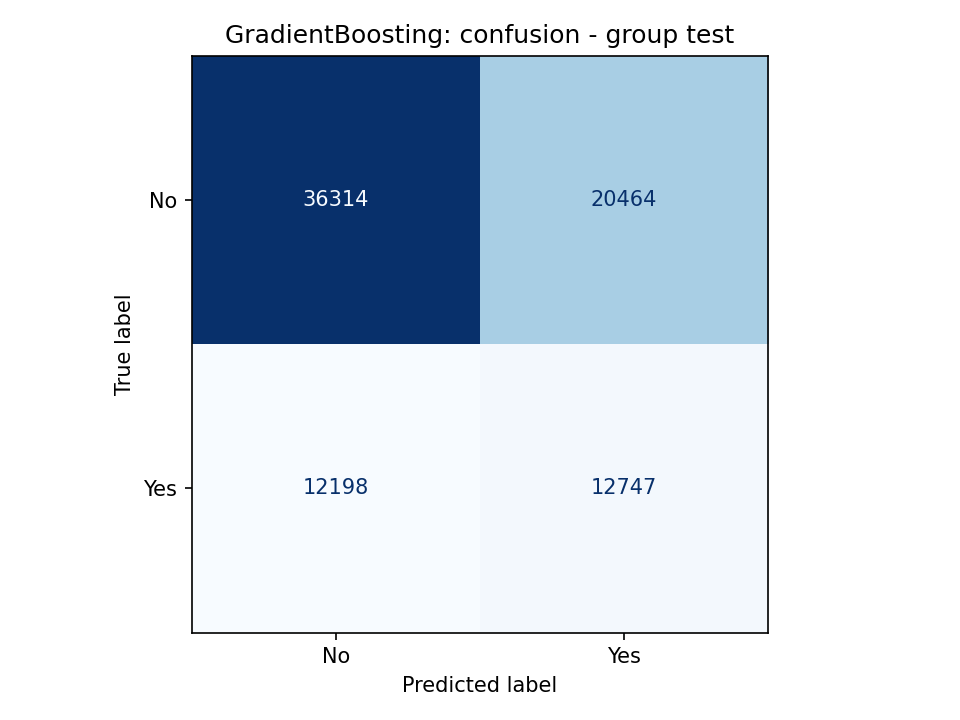

In [10]:
display(pd.read_csv(ROOT / f'results/{KEY}_confusion_matrix.csv', index_col=0))
display(Image(filename=str(ROOT / f'results/{KEY}_confusion.png')))

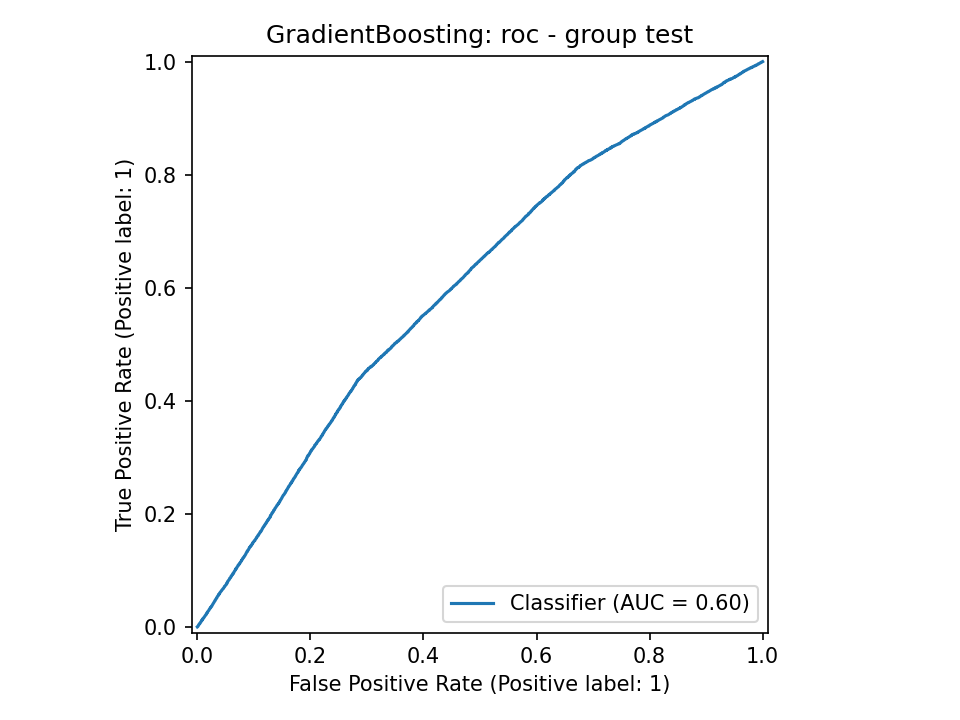

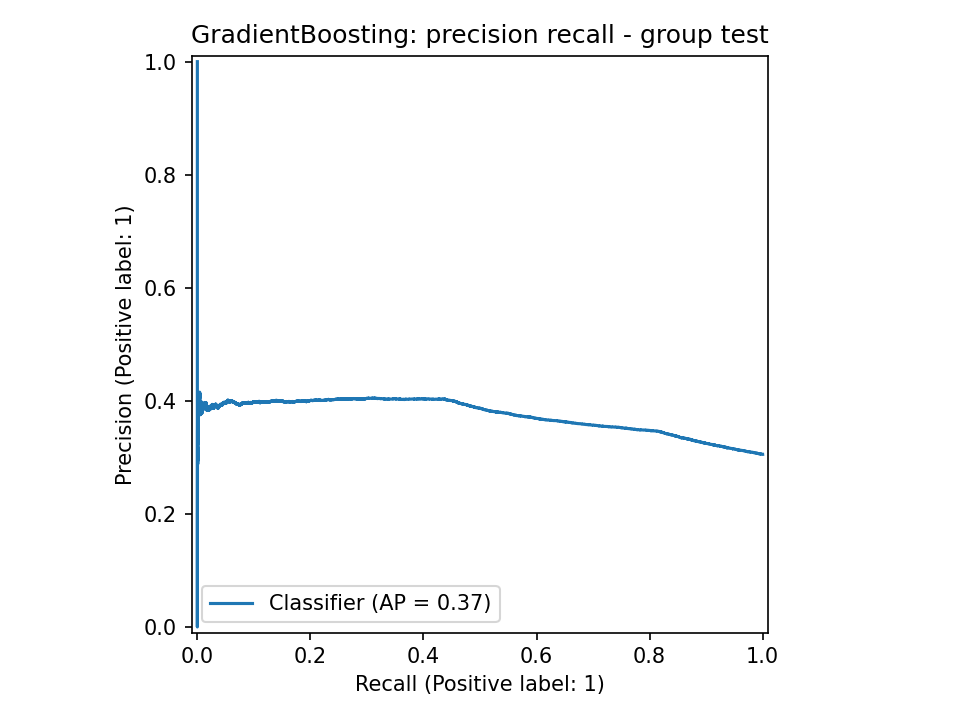

In [11]:
display(Image(filename=str(ROOT / f'results/{KEY}_roc.png')))
display(Image(filename=str(ROOT / f'results/{KEY}_precision_recall.png')))

In [12]:
interpretation = 'feature_importance' if KEY == 'GradientBoosting' else 'coefficients'
display(pd.read_csv(ROOT / f'results/{KEY}_{interpretation}.csv').head(10))

,feature,importance
0,encoded__Employment Status_Unemployed,0.477467
1,numeric__Income,0.374097
2,encoded__Smoking Status_Former,0.050141
3,encoded__Smoking Status_Non-smoker,0.046178
4,encoded__Education Level_Bachelor's Degree,0.038662
5,numeric__Age,0.009507
6,encoded__Sleep Patterns_Poor,0.000461
7,encoded__Alcohol Consumption_Moderate,0.000453
8,encoded__Marital Status_Married,0.000344
9,encoded__Dietary Habits_Moderate,0.000328


In [13]:
import joblib
artifact = joblib.load(ROOT / f'models/{KEY}.joblib')
X_test = pd.read_csv(ROOT / 'data/prepared/X_test.csv', nrows=5)
print('Prediction labels:', artifact['pipeline'].predict(X_test))
print('Prediction scores:', scores(artifact['pipeline'], X_test))
print(json.loads((ROOT / f'results/{KEY}_verification.json').read_text()))

Prediction labels: [1 0 0 0 1]
Prediction scores: [0.58263018 0.4992101  0.49591152 0.37029885 0.5882698 ]
{'reload_100_predictions_identical': True, 'all_metrics_recomputed_from_saved_predictions': True, 'no_test_fitting': True}


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid